Name: Sumit Khetre
PRN : 202402040017
ROll No: 284  


GRP Members:   
Ankita Beldar : 202402040023
Vedant gaygol : 202402040017

Github Link : https://github.com/sumitkhetre20/LSTM-Based-AI-Agent-for-Sequence-Prediction

# LSTM Assignment

Dataset Loading

In [ ]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text

print("Dataset length:", len(text))

print(text[:500])

Dataset length: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


Convert to Sentences

In [ ]:
sentences = text.split("\n")

sentences = [s.lower() for s in sentences if len(s) > 10]

print("Total sentences:", len(sentences))

Total sentences: 27660


Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")

tokenizer.fit_on_texts(sentences)

total_words = 5000

print("Vocabulary size:", total_words)

Vocabulary size: 5000


Generate Sequences

In [ ]:
input_sequences = []

for line in sentences:

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram = token_list[:i+1]

        input_sequences.append(n_gram)

print("Total sequences:", len(input_sequences))

Total sequences: 171057


Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_len = max(len(x) for x in input_sequences)

input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print(X.shape, y.shape)

(171057, 15) (171057,)


LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(5000, 128, input_shape=(max_len-1,)))

model.add(LSTM(128, return_sequences=True))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dense(5000, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5000)           │       325,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,992 (4.37 MB)

 Trainable params: 1,145,992 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [ ]:
history = model.fit(
    X,
    y,
    epochs=40,
    batch_size=64
)

Epoch 1/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.0602 - loss: 6.3058
Epoch 2/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.0838 - loss: 5.9022
Epoch 3/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.1013 - loss: 5.6749
Epoch 4/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.1107 - loss: 5.5249
Epoch 5/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.1165 - loss: 5.4045
Epoch 6/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.1210 - loss: 5.3062
Epoch 7/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.1247 - loss: 5.2240
Epoch 8/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.1265 - loss: 5.1527
Epoch 9/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.1296 - loss: 5.0902
Epoch 10/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.1325 - loss: 5.0318
Epoch 11/40
2673/2673 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.1344 - loss: 4.9799
Epoch 12/40
2673/26

Accuracy vs Loss

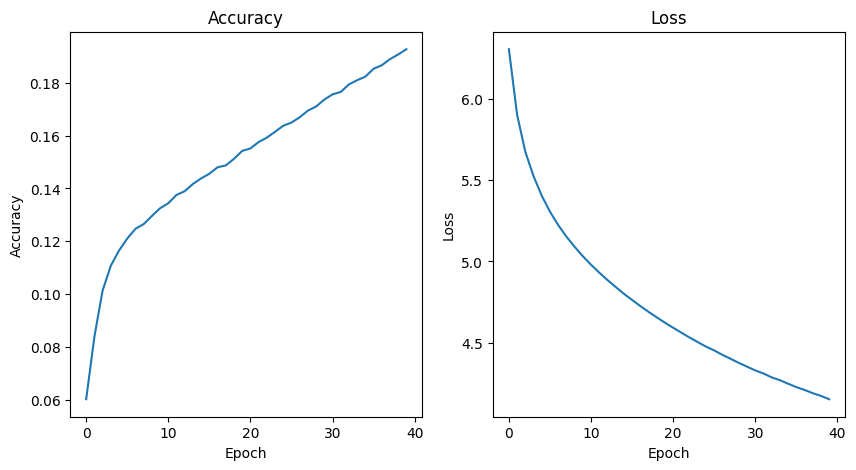

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

Prediction Function

In [ ]:
def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

    preds = model.predict(token_list)[0]

    top_k = preds.argsort()[-5:]

    predicted = np.random.choice(top_k)

    for word, index in tokenizer.word_index.items():

        if index == predicted:

            return word

Generate Text

In [ ]:
def generate_text(seed_text, next_words):

    for _ in range(next_words):

        next_word = predict_next_word(seed_text)

        seed_text = seed_text + " " + next_word

    return seed_text

In [ ]:
print(generate_text("my lord",5))
print(generate_text("i will",5))
print(generate_text("the king",5))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
my lord northumberland i find the way
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
i will and stay the king be
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
the king is <OOV> and made him


Save Model for FastAPI

In [ ]:
model.save("lstm_model.h5")

import pickle

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))

Download

In [ ]:
from google.colab import files

files.download("lstm_model.h5")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>